In [1]:
import os, pickle, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display

from plot_violin import (
    compute_rbo_distance, compute_jaccard_distance, compute_l2_distance,
    compute_rbo_baseline, compute_jaccard_baseline, compute_l2_baseline,
)

DATASETS   = ['german', 'diabetes', 'acs', 'gmsc']
MODELS     = ['dt', 'rf', 'xgb', 'mlp', 'ftt']
EXPLAINERS = ['kernel_shap', 'permutation_shap']
METHODS    = ['random', 'kmeans', 'pred_stratified', 'cte']
METRICS    = ['l2', 'jac', 'rbo']

DATASET_LABELS = {'german': 'German', 'diabetes': 'Diabetes', 'acs': 'ACS', 'gmsc': 'GMSC'}
MODEL_LABELS   = {'dt': 'DT', 'rf': 'RF', 'xgb': 'XGB', 'mlp': 'MLP', 'ftt': 'FTT'}
EXPL_LABELS    = {'kernel_shap': 'KernelSHAP', 'permutation_shap': 'PermSHAP'}
METHOD_LABELS  = {'random': 'Random', 'kmeans': 'KMeans',
                  'pred_stratified': 'Pred-Strat', 'cte': 'CTE'}
METRIC_LABELS  = {'l2': 'L2', 'jac': 'Top-3 Jaccard Distance', 'rbo': '1-RBO'}

N_BG_SEEDS = 5
N_CHUNKS   = {'german': 1, 'diabetes': 1, 'acs': 100, 'gmsc': 100}
N_FEATS    = {'german': 16, 'diabetes': 8, 'acs': 8, 'gmsc': 10}
JAC_K      = 3
RES_DIR    = 'results_tree'
PAIRS_5    = list(itertools.combinations(range(5), 2))  # 10 BG seed pairs

print('Constants loaded.')

Install with: pip install SciencePlots
✅ Analysis and plotting functions loaded successfully!
Constants loaded.


In [2]:
# ── Helper functions ──────────────────────────────────────────────────────────

def load_sv(ds, model, model_seed, method, s_idx, explainer='kernel_shap'):
    prefix = 'perm_' if explainer == 'permutation_shap' else ''
    n_ch   = N_CHUNKS[ds]

    def _chunk(c=None):
        base = f'{ds}_{model}_0_{model_seed}_{prefix}{method}_s{s_idx}'
        fn   = f'{base}_c{c}_sv.pkl' if c is not None else f'{base}_sv.pkl'
        p    = os.path.join(RES_DIR, fn)
        if not os.path.exists(p): return None
        with open(p, 'rb') as f: obj = pickle.load(f)
        return obj.values

    if n_ch == 1:
        return _chunk()
    arrs = [_chunk(c) for c in range(n_ch)]
    arrs = [a for a in arrs if a is not None]
    return np.concatenate(arrs, axis=0) if arrs else None


def pct_above(dist_arrays, threshold):
    """% of per-instance distances (flattened across all pairs) exceeding threshold."""
    if not dist_arrays:
        return float('nan')
    flat = np.concatenate(dist_arrays)
    return 100.0 * np.mean(flat > threshold)


def dist_fn(metric, v1, v2):
    if metric == 'rbo': return compute_rbo_distance(v1, v2)
    if metric == 'jac': return compute_jaccard_distance(v1, v2, k=JAC_K)
    if metric == 'l2':  return compute_l2_distance(v1, v2)


print('Helpers ready.')

Helpers ready.


In [3]:
# ── Baselines per dataset ─────────────────────────────────────────────────────

baselines = {}
for ds in DATASETS:
    d = N_FEATS[ds]
    r = max(1, d // 3)
    baselines[ds] = {
        'rbo': compute_rbo_baseline(n_features=d)['min'],
        'jac': compute_jaccard_baseline(d=d, r=JAC_K)['min'],
        'l2':  compute_l2_baseline(d=d, r=r)['min'],
    }
    print(f"{ds} (d={d}): "
          f"rbo>={baselines[ds]['rbo']:.4f}  "
          f"jac>={baselines[ds]['jac']:.4f}  "
          f"l2>={baselines[ds]['l2']:.4f}")

german (d=16): rbo>=0.4508  jac>=0.2980  l2>=0.1318
diabetes (d=8): rbo>=0.4853  jac>=0.3012  l2>=0.1160
acs (d=8): rbo>=0.4853  jac>=0.3012  l2>=0.1160
gmsc (d=10): rbo>=0.4752  jac>=0.3008  l2>=0.1250


In [4]:
# ── Main computation loop ─────────────────────────────────────────────────────
# table_data[metric][ds][model][explainer][method] = pct (float)

table_data = {
    mt: {ds: {model: {expl: {} for expl in EXPLAINERS} for model in MODELS}
         for ds in DATASETS}
    for mt in METRICS
}

for ds in DATASETS:
    for model in MODELS:
        for expl in EXPLAINERS:
            for method in METHODS:
                svs = [load_sv(ds, model, 0, method, s, expl) for s in range(N_BG_SEEDS)]
                svs = [a for a in svs if a is not None]

                for mt in METRICS:
                    dists = []
                    for i, j in PAIRS_5:
                        if i >= len(svs) or j >= len(svs): continue
                        n = min(len(svs[i]), len(svs[j]))
                        dists.append(dist_fn(mt, svs[i][:n], svs[j][:n]))
                    table_data[mt][ds][model][expl][method] = \
                        pct_above(dists, baselines[ds][mt])

        print(f'{ds}/{model}: done')

print('All done.')

german/dt: done
german/rf: done
german/xgb: done
german/mlp: done
german/ftt: done
diabetes/dt: done
diabetes/rf: done
diabetes/xgb: done
diabetes/mlp: done
diabetes/ftt: done
acs/dt: done
acs/rf: done
acs/xgb: done
acs/mlp: done
acs/ftt: done
gmsc/dt: done
gmsc/rf: done
gmsc/xgb: done
gmsc/mlp: done
gmsc/ftt: done
All done.


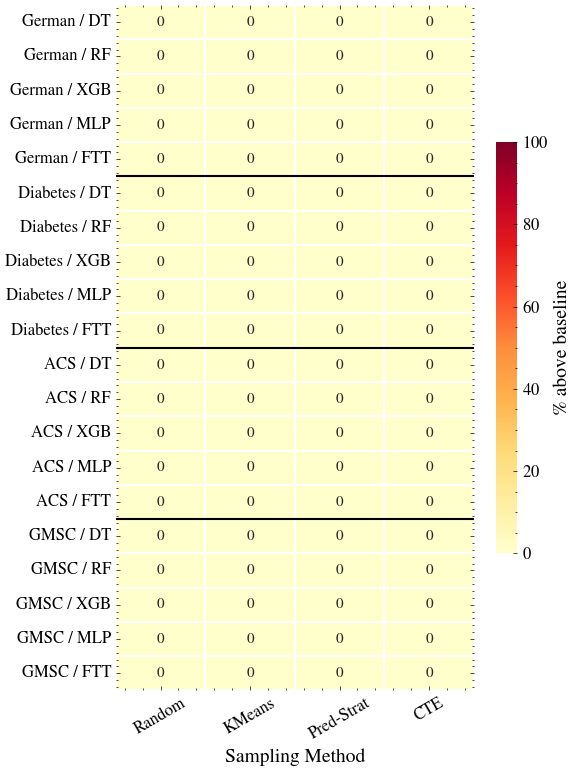

Saved: tables/bg_heatmap_l2_kernel_shap.pdf


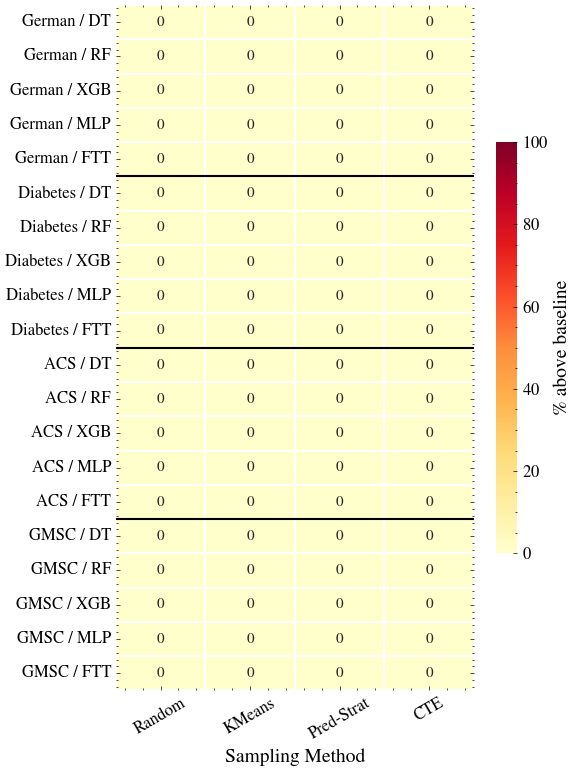

Saved: tables/bg_heatmap_l2_permutation_shap.pdf


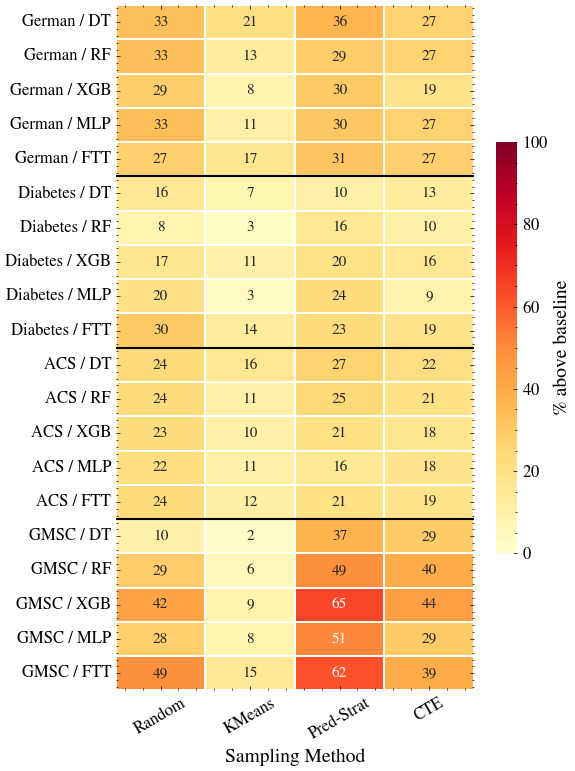

Saved: tables/bg_heatmap_jac_kernel_shap.pdf


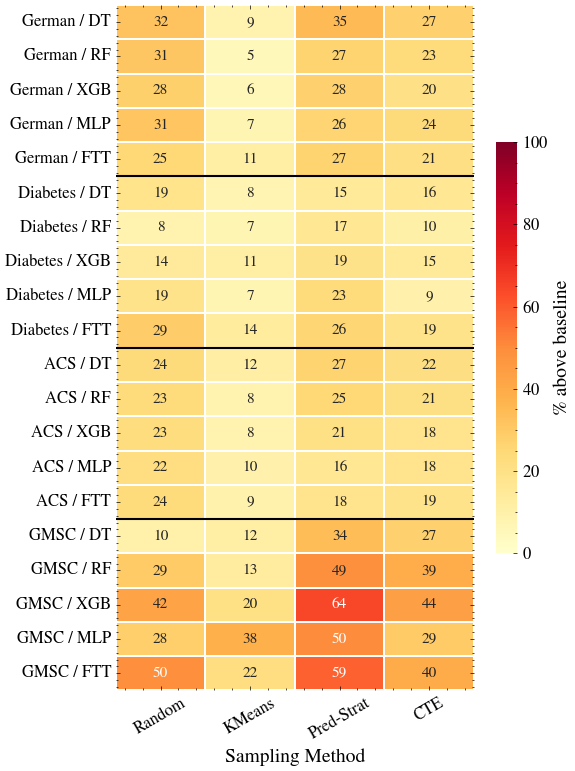

Saved: tables/bg_heatmap_jac_permutation_shap.pdf


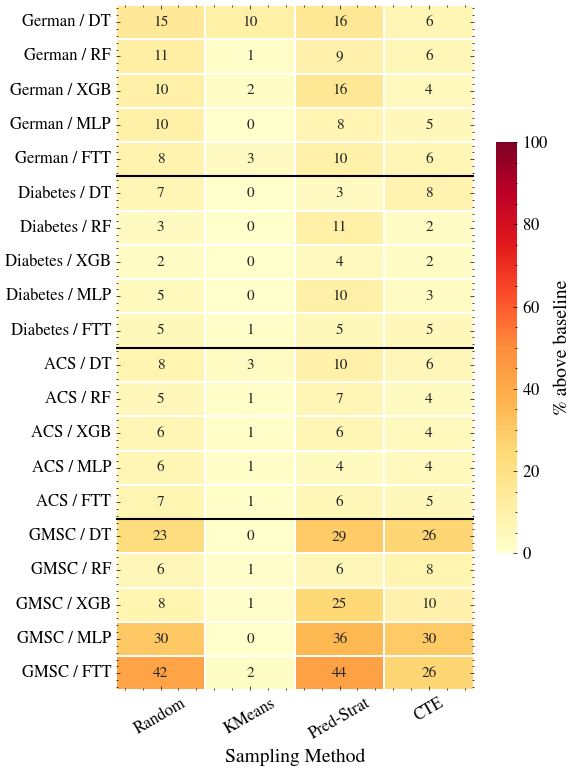

Saved: tables/bg_heatmap_rbo_kernel_shap.pdf


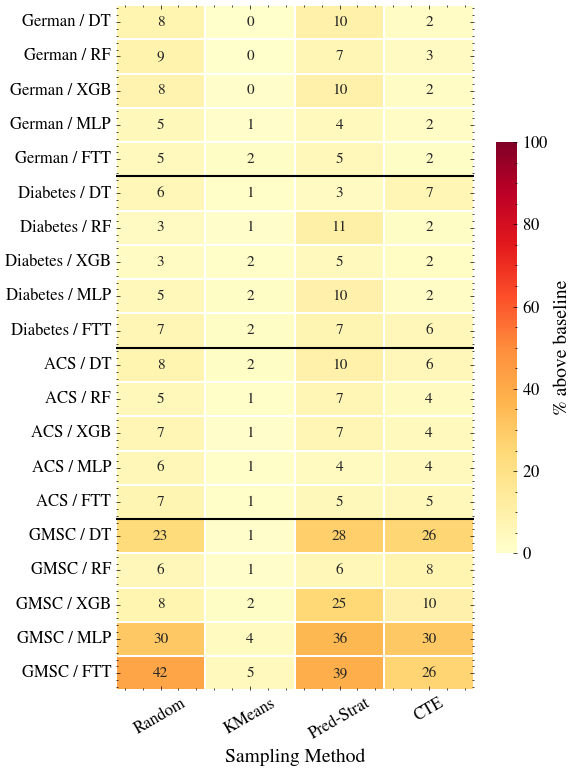

Saved: tables/bg_heatmap_rbo_permutation_shap.pdf


In [5]:
# ── Heatmaps: one figure per (metric, explainer) ─────────────────────────────

import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'no-latex'])
import matplotlib
matplotlib.rcParams.update({
    'font.size':        13,
    'axes.labelsize':   14,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
})

os.makedirs('tables', exist_ok=True)

ROW_LABELS = [f'{DATASET_LABELS[ds]} / {MODEL_LABELS[m]}'
              for ds in DATASETS for m in MODELS]
COL_LABELS = [METHOD_LABELS[m] for m in METHODS]
row_bounds = [k * len(MODELS) for k in range(1, len(DATASETS))]

def make_annot(mat, fmt):
    """Custom annotation: empty string for NaN, formatted number otherwise."""
    out = np.empty(mat.shape, dtype=object)
    for idx in np.ndindex(mat.shape):
        v = mat[idx]
        out[idx] = '' if np.isnan(v) else format(v, fmt)
    return out

for mt in METRICS:
    for expl in EXPLAINERS:
        fig, ax = plt.subplots(figsize=(6, 8))

        mat = np.full((len(DATASETS) * len(MODELS), len(METHODS)), float('nan'))
        for i, ds in enumerate(DATASETS):
            for j, model in enumerate(MODELS):
                for l, method in enumerate(METHODS):
                    mat[i * len(MODELS) + j, l] = \
                        table_data[mt][ds][model][expl][method]

        df_heat = pd.DataFrame(mat, index=ROW_LABELS, columns=COL_LABELS)

        sns.heatmap(df_heat, ax=ax, vmin=0, vmax=100, cmap='YlOrRd',
                    annot=make_annot(mat, '.0f'), fmt='', annot_kws={'size': 11},
                    linewidths=0.3, linecolor='white',
                    cbar_kws={'label': '% above baseline', 'shrink': 0.6})

        for rb in row_bounds:
            ax.axhline(rb, color='black', linewidth=1.5)

        ax.set_xlabel('Sampling Method', fontsize=14)
        ax.tick_params(axis='x', rotation=30, labelsize=12)
        ax.tick_params(axis='y', rotation=0,  labelsize=12)

        fig.tight_layout()
        fname = f'tables/bg_heatmap_{mt}_{expl}.pdf'
        fig.savefig(fname, bbox_inches='tight')
        plt.show(); plt.close(fig)
        print(f'Saved: {fname}')

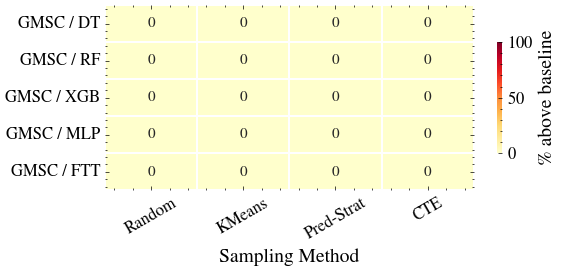

Saved: tables/bg_heatmap_l2_kernel_shap_gmsc.pdf


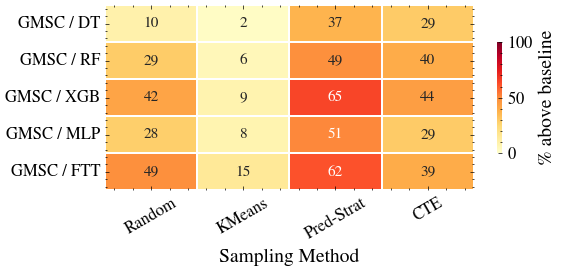

Saved: tables/bg_heatmap_jac_kernel_shap_gmsc.pdf


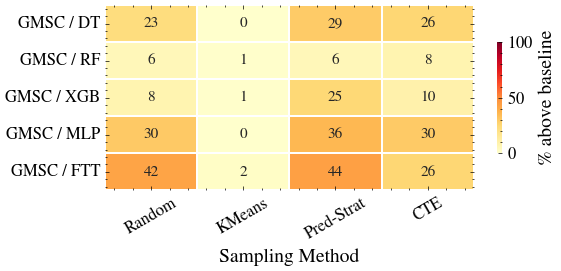

Saved: tables/bg_heatmap_rbo_kernel_shap_gmsc.pdf


In [6]:
# ── GMSC-only heatmaps, kernel_shap only (for paper) ──────────────────────────
DS_GMSC = 'gmsc'
EXPL_PAPER = 'kernel_shap'
gmsc_row_labels = [f'{DATASET_LABELS[DS_GMSC]} / {MODEL_LABELS[m]}' for m in MODELS]

for mt in METRICS:
    mat_gmsc = np.full((len(MODELS), len(METHODS)), float('nan'))
    for j, model in enumerate(MODELS):
        for l, method in enumerate(METHODS):
            mat_gmsc[j, l] = table_data[mt][DS_GMSC][model][EXPL_PAPER][method]

    df_gmsc = pd.DataFrame(mat_gmsc, index=gmsc_row_labels, columns=COL_LABELS)

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.heatmap(df_gmsc, ax=ax, vmin=0, vmax=100, cmap='YlOrRd',
                annot=make_annot(mat_gmsc, '.0f'), fmt='', annot_kws={'size': 11},
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': '% above baseline', 'shrink': 0.6})

    ax.set_xlabel('Sampling Method', fontsize=14)
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=12)

    fig.tight_layout()
    fname = f'tables/bg_heatmap_{mt}_{EXPL_PAPER}_gmsc.pdf'
    fig.savefig(fname, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f'Saved: {fname}')